# Multi-MiniPAR capture

Reads the **reference TIA PAR sensor** and every **MiniPAR on the USB hub** in lockstep, waits
until *all* of them are stable simultaneously, and appends **one row per device** to a CSV.

Schema written to disk:

```
timestamp,measurement,tia_par,miniPAR,metadata,f1_415,f2_445,f3_480,f4_515,f5_555,f6_590,f7_630,f8_680,clear,nir,gain,aint,astep
```

* `measurement` — capture counter. All devices in one capture share it; the next id is taken
  from `max(measurement) + 1` **re-read from the file** at save time, so it stays unique even
  if another session appended in the meantime.
* `miniPAR` — `miniPAR_<MAC>`, e.g. `miniPAR_A0B7651C4D3E`. The MAC comes from the firmware's
  JSON frame header (`device_id`); line mode has no command for it.
* `tia_par`, `metadata` — shared by every row of a capture (one reference, one tag).
* `f1_415 ... nir` — **raw ADC counts** from `spec_raw` (10 AS7341 channels, device order).
* `gain`, `aint`, `astep` — **per device**, read back from that device's `spec_status`.

**Stability rule** — over a rolling window of the last *N* samples, the peak-to-peak spread
must be within `STABLE_TOL` of the window mean for the TIA PAR **and for every device's
spectral total, all at the same time**. One slow device holds up the whole capture, which is
the point: the rows in a measurement are only comparable if they were taken under the same
light.

Every instrument — the TIA included — is polled concurrently, one thread per port. Wall-clock
per sample therefore stays at about one integration time no matter how many are plugged in,
and all the readings in a sample share the same slice of wall clock.


## 1. Imports and configuration


In [34]:
import json
import re
import time
from collections import deque
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import numpy as np
import pandas as pd
import serial
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from IPython.display import clear_output, display

from helpers import serial_ports

BAUD_RATE = 115200

# --- Device identity (mirrors Firmware/include/app/device_config.h) -------
PRODUCT_NAME = 'MiniPAR'
JSON_FOOTER  = '7A1E3AA1'     # sentinel appended to every JSON frame
MAC_QUERY    = '[{"set":[{"label":"hello"}]}]'   # cheapest frame that carries device_id

# --- CSV schema ------------------------------------------------------------
SPECTRAL_CHANNELS = ['f1_415', 'f2_445', 'f3_480', 'f4_515',
                     'f5_555', 'f6_590', 'f7_630', 'f8_680',
                     'clear',  'nir']
SETTING_COLUMNS = ['gain', 'aint', 'astep']   # aint == the AS7341 ATIME register
CSV_COLUMNS = (['timestamp', 'measurement', 'tia_par', 'miniPAR', 'metadata']
               + SPECTRAL_CHANNELS + SETTING_COLUMNS)
N_SPEC = len(SPECTRAL_CHANNELS)               # 10

# --- Where readings are stored --------------------------------------------
_here = Path.cwd()
DATA_DIR = _here.parent / 'data' if (_here.parent / 'data').is_dir() else _here
CSV_PATH = DATA_DIR / 'multi_par_spec.csv'

# --- Stability criterion ---------------------------------------------------
STABLE_WINDOW   = 4      # consecutive samples that must agree
STABLE_TOL      = 0.01   # 1 % peak-to-peak spread relative to the window mean
STABLE_MAX_WAIT = 90.0   # s, give up waiting after this (more devices -> slower samples)
SETTLE_S        = 0.10   # pause between samples (a spec read already takes ~0.6 s)
TIA_ABS_FLOOR   = 0.05   # TIA ptp always treated as stable (keeps dark readings from spinning)
SPEC_ABS_FLOOR  = 8.0    # spectral-total ptp, raw counts, likewise

SATURATION_COUNT = 65535  # AS7341 full-scale raw count

print(f'CSV target : {CSV_PATH}')
print(f'Stability  : {STABLE_WINDOW} samples within {STABLE_TOL * 100:.1f} % '
      f'on the TIA and on every device')


CSV target : c:\Users\LudovicoCaracciolo\Documents\Git-repo\miniPar\data\multi_par_spec.csv
Stability  : 4 samples within 1.0 % on the TIA and on every device


## 2. Find every MiniPAR on the hub

Each port is probed with `hello`; anything answering `MiniPAR,...` is kept. Opening a port
resets the ESP32-C3, so the probe waits out the boot banner before deciding. Commands are
sent **CRLF-terminated**: the MiniPAR firmware drops `\r`, but MicroPython's readline only
accepts `\r` as Enter, so a bare LF strands `hello` in the TIA's line buffer.

The TIA is then looked for on the ports that are *not* MiniPARs, by calling `getPAR()` and
checking a number comes back. That identifies the board and proves the function is live in
one step — unlike the raw-REPL banner, which Ctrl-A only produces on an empty line (with
characters pending it just moves the cursor and replies `\x1b[5D`).


In [35]:
def _read_until_quiet(ser, quiet_s=0.35, max_s=2.5):
    """Read everything the port sends until it has been silent for `quiet_s`."""
    chunks = []
    deadline = time.monotonic() + max_s
    last = time.monotonic()
    while time.monotonic() < deadline:
        data = ser.read_all()
        if data:
            chunks.append(data)
            last = time.monotonic()
        elif time.monotonic() - last >= quiet_s:
            break
        time.sleep(0.05)
    return b''.join(chunks).decode(errors='ignore')


def probe_minipar(port, timeout=2.0):
    """Return the firmware banner if `port` is a MiniPAR, else None.

    The command is terminated with CRLF, not bare LF. The MiniPAR firmware drops '\r'
    outright (main.cpp) so CRLF is identical to LF for it - but MicroPython's readline
    only accepts '\r' as Enter, so a bare LF would leave 'hello' sitting in the TIA's
    line buffer and break the next probe.

    DTR/RTS are held low while probing so the ESP32-C3 cannot drop into its ROM
    downloader, then put back before closing when the port turns out not to be ours:
    a MicroPython board reads a deasserted DTR as 'host disconnected'.
    """
    try:
        with serial.Serial(port, baudrate=BAUD_RATE, timeout=timeout) as ser:
            ser.dtr = False
            ser.rts = False
            time.sleep(0.6)              # let it finish booting after the open-reset
            ser.reset_input_buffer()
            ser.write(b'hello\r\n')
            ser.flush()
            time.sleep(0.4)
            text = _read_until_quiet(ser)
            banner = next((line.strip() for line in text.splitlines()
                           if line.startswith(PRODUCT_NAME)), None)
            if banner is None:           # not ours - restore the handshake lines
                ser.dtr = True
                ser.rts = True
                time.sleep(0.2)
            return banner
    except (OSError, serial.SerialException):
        return None


def _first_float(text):
    """First line of `text` that parses as a number, skipping the REPL echo and prompt."""
    for line in text.splitlines():
        token = line.replace('>>>', '').replace('getPAR()', '').strip()
        if not token:
            continue
        try:
            return float(token)
        except ValueError:
            continue
    return None


def probe_tia(port, timeout=2.0, attempts=2, verbose=True):
    """True if `port` answers getPAR() with a number.

    That single call is the whole test: the reference sensor is a MicroPython REPL with
    getPAR() already defined by main.py, so calling it identifies the device *and* proves
    the one function we need is live. Terminated CRLF because MicroPython's readline takes
    only '\r' as Enter - and if some earlier probe did strand a partial line, this command
    completes it and the second attempt lands on a clean prompt.
    """
    for attempt in range(1, attempts + 1):
        try:
            with serial.Serial(port, baudrate=BAUD_RATE, timeout=timeout) as ser:
                ser.dtr = True       # a MicroPython CDC stays mute until DTR is asserted
                ser.rts = True
                ser.reset_input_buffer()
                ser.reset_output_buffer()
                time.sleep(0.8)      # opening resets the board; let it come back
                ser.write(b'getPAR()\r\n')
                ser.flush()
                time.sleep(0.5)
                text = _read_until_quiet(ser)
                value = _first_float(text)
                if value is not None:
                    if verbose:
                        print(f'    {port}: getPAR() -> {value}')
                    return True
                if verbose:
                    print(f'    {port} try {attempt}: {text.strip()[:80]!r}')
        except (OSError, serial.SerialException) as exc:
            if verbose:
                print(f'    {port}: {exc}')
            return False
    return False


def find_tia(exclude=()):
    for port in serial_ports():
        if port in exclude:
            continue
        if probe_tia(port):
            return port
    return None


def sniff(port, message=b'\x01', wait=1.0):
    """Diagnostic: open `port`, send `message`, print verbatim whatever comes back."""
    with serial.Serial(port, baudrate=BAUD_RATE, timeout=2.0) as ser:
        ser.dtr = True
        ser.rts = True
        ser.reset_input_buffer()
        time.sleep(0.8)
        ser.write(message)
        ser.flush()
        time.sleep(wait)
        print(repr(_read_until_quiet(ser)))


print('Scanning serial ports...')
ports = serial_ports()
print(f'  {len(ports)} port(s) present: {", ".join(ports) if ports else "none"}')

MINIPAR_PORTS = []
for port in ports:
    banner = probe_minipar(port)
    if banner:
        MINIPAR_PORTS.append(port)
        print(f'  {port}: {banner}')

print(f'\n{len(MINIPAR_PORTS)} MiniPAR(s): {", ".join(MINIPAR_PORTS) if MINIPAR_PORTS else "none"}')

print('\nScanning for the reference sensor (TIA)...')
PORT_REF = find_tia(exclude=MINIPAR_PORTS)
print(f'  PORT_REF: {PORT_REF}')
if PORT_REF is None:
    print('  The quoted text above is what each non-MiniPAR port actually replied.')
    print("  To look closer:  sniff('COM66', b'getPAR()\\r\\n')")
    print('  then set PORT_REF by hand in the next cell.')


Scanning serial ports...
  4 port(s) present: COM66, COM67, COM68, COM69
  COM67: MiniPAR,1.1
  COM68: MiniPAR,1.1
  COM69: MiniPAR,1.1

3 MiniPAR(s): COM67, COM68, COM69

Scanning for the reference sensor (TIA)...
    COM66: getPAR() -> 1140.9762
  PORT_REF: COM66


In [36]:
# Override here if the scan missed something, e.g.
# MINIPAR_PORTS = ['COM64', 'COM65', 'COM66']
# PORT_REF      = 'COM5'

assert MINIPAR_PORTS, 'No MiniPAR found - check the hub, or set MINIPAR_PORTS by hand'

assert PORT_REF, 'No TIA found. '
print(f'{len(MINIPAR_PORTS)} MiniPAR(s) @ {", ".join(MINIPAR_PORTS)}    TIA @ {PORT_REF}')


3 MiniPAR(s) @ COM67, COM68, COM69    TIA @ COM66


## 3. Serial layer

Every port is opened **once** and held open. Reopening per read re-asserts DTR/RTS, resets the
board and costs a second or more — unusable inside a stability loop, and worse with N devices.


In [37]:
MAC_RE = re.compile(r'^(?:[0-9A-Fa-f]{2}[:-]){5}[0-9A-Fa-f]{2}$')


class MiniPar:
    """Persistent line-mode connection to one MiniPAR (ESP32-C3, USB CDC).

    The firmware handles one command per newline-terminated line and always closes its
    reply with a newline (`main.cpp` -> `Serial.println()`), so a blocking `readline()`
    with a generous timeout is enough. The boot banner is drained before the first command
    so it can never be mistaken for a reply.
    """

    def __init__(self, port, baudrate=BAUD_RATE, timeout=3.0):
        self.port = port
        self.ser = serial.Serial(port, baudrate=baudrate, timeout=timeout)
        self.ser.setDTR(False)          # keep the ESP32 out of bootloader mode
        self.ser.setRTS(False)
        time.sleep(0.3)
        self.ser.write(b'\r\n')         # terminate any partial line left in the firmware buffer
        self.ser.flush()
        self._drain()

        self.banner = self.handshake()
        if not self.banner:
            self.close()
            raise RuntimeError(f'{port} did not answer as a {PRODUCT_NAME}')
        self.label = self.identify()

    def __repr__(self):
        return f'<{self.label} on {self.port}>'

    def close(self):
        try:
            self.ser.close()
        except Exception:
            pass

    def _drain(self, quiet_s=0.3, max_s=4.0):
        """Read and discard until the port has been silent for `quiet_s`."""
        deadline = time.monotonic() + max_s
        last = time.monotonic()
        while time.monotonic() < deadline:
            if self.ser.read_all():
                last = time.monotonic()
            elif time.monotonic() - last >= quiet_s:
                return
            time.sleep(0.05)

    def handshake(self, attempts=4):
        """Return the `MiniPAR,<version>[,<fw>]` banner, or None."""
        for _ in range(attempts):
            self._drain()
            self.ser.write(b'hello\n')
            self.ser.flush()
            time.sleep(0.3)
            for line in self.ser.read_all().decode(errors='ignore').splitlines():
                if line.startswith(PRODUCT_NAME):
                    return line.strip()
        return None

    def device_id(self):
        """(device_id field, whole frame) from the JSON header - line mode has no MAC command."""
        self._drain()
        self.ser.write(MAC_QUERY.encode())
        self.ser.flush()
        frame = self.ser.readline().decode(errors='ignore').strip()
        match = re.search(r'"device_id"\s*:\s*"([^"]+)"', frame)
        if not match:
            raise RuntimeError(f'No device_id in the JSON frame from {self.port}: {frame!r}')
        return match.group(1), frame

    def get_name(self):
        """The name stored in NVS ('NoName' until set_name is used)."""
        try:
            return self.cmd('get_name')
        except RuntimeError:
            return ''

    def set_name(self, name):
        """Give this unit a persistent name (max 20 chars) - survives power cycles."""
        return self.cmd(f'set_name,{name}')

    def identify(self):
        """Resolve a stable per-device label.

        Preference order: the MAC from the JSON header, then the NVS device name, then the
        port. Older firmware puts the chip model ('esp32-c3') in `device_id` instead of the
        MAC, so the value is checked against a MAC pattern rather than trusted blindly.
        `id_source` records which one was used, so the caller can warn.
        """
        self.device_id_raw, self.frame = self.device_id()
        if MAC_RE.match(self.device_id_raw):
            self.mac = self.device_id_raw.upper().replace('-', ':')
            self.id_source = 'mac'
            return f'miniPAR_{self.mac.replace(":", "")}'

        self.mac = None
        name = self.get_name()
        if name and name.lower() not in {'noname', ''} and not name.startswith('error'):
            self.id_source = 'name'
            return f'miniPAR_{name}'

        self.id_source = 'port'
        return f'miniPAR_{self.port}'

    def cmd(self, text, retries=2):
        """Send one command, return its single-line reply (stripped)."""
        for _ in range(retries + 1):
            self.ser.reset_input_buffer()
            self.ser.write((text + '\n').encode())
            self.ser.flush()
            reply = self.ser.readline().decode(errors='ignore').strip()
            if reply:
                if reply.startswith('error:'):
                    raise RuntimeError(f'{self.port} rejected {text!r}: {reply}')
                return reply
        raise RuntimeError(f'No reply from {self.port} for {text!r} '
                           f'(timeout {self.ser.timeout} s)')

    def spec_raw(self):
        """`spec_raw` -> (raw ADC counts per channel, model name)."""
        reply = self.cmd('spec_raw')
        parts = [p.strip() for p in reply.split(',') if p.strip()]
        model = ''
        if parts and not (parts[0][0].isdigit() or parts[0][0] == '-'):
            model, parts = parts[0], parts[1:]
        if len(parts) != N_SPEC:
            raise RuntimeError(f'{self.label}: expected {N_SPEC} channels, '
                               f'got {len(parts)}: {reply!r}')
        return np.array([float(p) for p in parts], dtype=float), model

    def status(self):
        """`spec_status` -> {'model': 'AS7341', 'available': 1, 'atime': .., 'astep': .., 'gain': ..}."""
        reply = self.cmd('spec_status')
        out = {}
        for field in reply.split(','):
            if '=' not in field:
                continue
            key, value = (s.strip() for s in field.split('=', 1))
            try:
                out[key] = int(value)
            except ValueError:
                out[key] = value
        return out

    def par(self, raw=False):
        """This device's own PAR estimate (`par` / `par_raw`) - not written to the CSV."""
        return float(self.cmd('par_raw' if raw else 'par'))

    def set_setting(self, name, value):
        """name in {'gain', 'atime', 'astep'}; returns the value the device echoes back."""
        if name not in {'gain', 'atime', 'astep'}:
            raise ValueError(f'unknown setting {name!r}')
        return int(self.cmd(f'spec_set_{name},{int(value)}'))


class TiaRef:
    """Persistent connection to the reference TIA PAR sensor (a MicroPython REPL).

    `getPAR()` is typed at the REPL, so the reply stream is: the echoed command, the
    printed value, then a bare `>>> ` prompt. Lines are read until one parses as a float
    rather than assuming a fixed echo count.
    """

    label = 'TIA'

    def __init__(self, port, baudrate=BAUD_RATE, timeout=2.0):
        self.port = port
        self.ser = serial.Serial(port, baudrate=baudrate, timeout=timeout)
        self.ser.dtr = True             # MicroPython CDC stays mute until DTR is asserted
        self.ser.rts = True
        time.sleep(0.8)                 # same settle the probe needs: opening resets it
        self.ser.reset_input_buffer()

    def close(self):
        try:
            self.ser.close()
        except Exception:
            pass

    def par(self, max_lines=8, attempts=2):
        """One PAR value, retried once - a single dropped reply should not kill a capture."""
        seen = []
        for _ in range(attempts):
            self.ser.reset_input_buffer()
            self.ser.write(b'getPAR()\r\n')
            self.ser.flush()
            for _ in range(max_lines):
                raw = self.ser.readline()
                if not raw:                 # read timed out, nothing more is coming
                    break
                line = raw.decode(errors='ignore').strip()
                if not line:                # a genuinely blank line, keep reading
                    continue
                seen.append(line)
                token = line.replace('>>>', '').replace('getPAR()', '').strip()
                if not token:
                    continue
                try:
                    return float(token)
                except ValueError:
                    continue
        raise RuntimeError(f'No numeric PAR from the TIA on {self.port}; saw {seen!r}')


def gain_multiplier(gain_reg):
    """AS7341 GAIN register -> multiplier: 0 -> 0.5x, n -> 2**(n-1). Mirrors the firmware."""
    gain_reg = int(gain_reg)
    return 0.5 if gain_reg == 0 else float(1 << (gain_reg - 1))


DEVICES = []
TIA = None


def close_links():
    global DEVICES, TIA
    for link in list(DEVICES) + ([TIA] if TIA is not None else []):
        link.close()
    DEVICES = []
    TIA = None


def open_links():
    """(Re)open every port. Safe to re-run - existing handles are closed first.

    Devices are sorted by label so their colours and row order stay identical between runs.
    """
    global DEVICES, TIA
    close_links()
    opened = []
    for port in MINIPAR_PORTS:
        dev = MiniPar(port)
        opened.append(dev)
        print(f'  {dev.port:8s} {dev.banner:22s} device_id={dev.device_id_raw!r:20s} '
              f'-> {dev.label}  (via {dev.id_source})')

    # A label collision would silently merge two devices into one series - disambiguate loudly.
    labels = [d.label for d in opened]
    dupes = {label for label in labels if labels.count(label) > 1}
    if dupes:
        for dev in opened:
            if dev.label in dupes:
                dev.label = f'{dev.label}_{dev.port}'
        print(f'\nWARNING: {len(dupes)} label(s) were not unique; the port has been appended. '
              f'Port numbers move between reboots, so this is not a durable id.')

    weak = [d for d in opened if d.id_source != 'mac']
    if weak:
        example = weak[0]
        print(f'\nWARNING: {len(weak)} of {len(opened)} device(s) do not report a MAC. '
              f'device_id = {example.device_id_raw!r}, banner = {example.banner!r}.')
        print('  This firmware predates the MAC being written into the JSON header '
              '(Firmware/src/app/commands.cpp puts esp_efuse_mac_get_default there and')
        print('  prints a 3-field banner). Either reflash from Firmware/, or give each unit')
        print("  a persistent name once:  DEVICES[0].set_name('unit_a')  then re-run this cell.")

    DEVICES = sorted(opened, key=lambda d: d.label)
    if PORT_REF is not None:
        TIA = TiaRef(PORT_REF)
    return DEVICES, TIA


print('Opening devices...')
open_links()

print()
display(pd.DataFrame([{'miniPAR': d.label, 'port': d.port, 'id_source': d.id_source,
                       'device_id': d.device_id_raw, 'name': d.get_name(), **d.status()}
                      for d in DEVICES]))
print('TIA PAR :', TIA.par() if TIA is not None else 'not connected')


Opening devices...
  COM67    MiniPAR,1.1            device_id='esp32-c3'           -> miniPAR_ValidDevice_1  (via name)
  COM68    MiniPAR,1.1            device_id='esp32-c3'           -> miniPAR_miniPAR  (via name)
  COM69    MiniPAR,1.1            device_id='esp32-c3'           -> miniPAR_ValidDevice_2  (via name)

  This firmware predates the MAC being written into the JSON header (Firmware/src/app/commands.cpp puts esp_efuse_mac_get_default there and
  prints a 3-field banner). Either reflash from Firmware/, or give each unit
  a persistent name once:  DEVICES[0].set_name('unit_a')  then re-run this cell.



,miniPAR,port,id_source,device_id,name,model,available,atime,astep,gain
0,miniPAR_ValidDevice_1,COM67,name,esp32-c3,ValidDevice_1,AS7341,1,100,999,2
1,miniPAR_ValidDevice_2,COM69,name,esp32-c3,ValidDevice_2,AS7341,1,100,999,2
2,miniPAR_miniPAR,COM68,name,esp32-c3,miniPAR,AS7341,1,100,999,2


TIA PAR : 1140.5246


## 4. Stability-gated read across all devices

`read_stable_multi()` samples the TIA and every MiniPAR in lockstep and only returns once the
rolling window is quiet for **all** of them. Within a single sample every instrument is read
**concurrently** — the TIA is submitted to the thread pool alongside the spectrometers, not
before them — so a sample describes one instant of light instead of a ~0.6 s sweep during
which the lamp could move. Per device it also:

* re-reads `spec_status` afterwards and refuses the capture if `gain`/`aint`/`astep` moved
  mid-run,
* flags any channel that hit full scale (65535),
* aggregates the accepted window with a per-channel **median** (every sample in it is within
  tolerance by construction, so this is free noise reduction — `aggregate='last'` gives the
  raw final sample instead; note an even `STABLE_WINDOW` medians to half-counts).

A relative tolerance alone cannot settle near darkness, where a fraction of a count is an
infinite relative change; `TIA_ABS_FLOOR` / `SPEC_ABS_FLOOR` give it an absolute escape hatch.


In [38]:
def _spread(values, abs_floor):
    """Peak-to-peak spread of a window -> (spread relative to its mean, within absolute floor)."""
    a = np.asarray(values, dtype=float)
    ptp = float(np.ptp(a))
    mean = float(np.mean(np.abs(a)))
    rel = ptp / mean if mean > 1e-12 else np.inf
    return rel, ptp <= abs_floor


def read_stable_multi(devices=None, tia=None, window=STABLE_WINDOW, tol=STABLE_TOL,
                      max_wait_s=STABLE_MAX_WAIT, settle_s=SETTLE_S,
                      aggregate='median', verbose=True):
    """Sample the TIA + every MiniPAR until all of them hold steady at the same time.

    Within a sample every instrument is read concurrently, so one row of history describes
    one instant of light rather than a sweep across instruments.

    Returns a dict with the shared reading (tia_par, diagnostics, histories) and a
    per-device sub-dict keyed by `miniPAR` label.
    """
    devices = DEVICES if devices is None else devices
    tia = TIA if tia is None else tia
    if not devices:
        raise RuntimeError('No devices open - run open_links() first.')

    settings_before = {d.label: d.status() for d in devices}

    tia_hist = deque(maxlen=window)
    spec_hist = {d.label: deque(maxlen=window) for d in devices}
    tia_all = []
    total_all = {d.label: [] for d in devices}

    t0 = time.monotonic()
    n = 0
    rel_tia = np.inf
    rel_dev = {d.label: np.inf for d in devices}
    stable = False

    # One worker per instrument, TIA included, so nothing has to queue.
    n_workers = len(devices) + (1 if tia is not None else 0)
    with ThreadPoolExecutor(max_workers=n_workers) as pool:
        while True:
            # Every read is submitted before any result is awaited, so the TIA sample and
            # all the spectral integrations happen over the same stretch of wall clock
            # rather than back to back. Reading the TIA first and the spectrometers after
            # would put roughly one integration time between them, and a sample pair taken
            # either side of a light change is exactly what the stability gate exists to
            # prevent.
            tia_future = pool.submit(tia.par) if tia is not None else None
            futures = {dev.label: pool.submit(dev.spec_raw) for dev in devices}

            tia_value = tia_future.result() if tia_future is not None else float('nan')
            samples = {label: future.result() for label, future in futures.items()}
            n += 1

            tia_hist.append(tia_value)
            tia_all.append(tia_value)
            for dev in devices:
                spec, _model = samples[dev.label]
                spec_hist[dev.label].append(spec)
                total_all[dev.label].append(float(spec.sum()))

            if len(tia_hist) == window:
                if tia is None:
                    rel_tia, tia_ok = 0.0, True
                else:
                    rel_tia, tia_flat = _spread(tia_hist, TIA_ABS_FLOOR)
                    tia_ok = rel_tia <= tol or tia_flat
                dev_ok = {}
                for dev in devices:
                    totals = [float(s.sum()) for s in spec_hist[dev.label]]
                    rel, flat = _spread(totals, SPEC_ABS_FLOOR)
                    rel_dev[dev.label] = rel
                    dev_ok[dev.label] = rel <= tol or flat
                stable = tia_ok and all(dev_ok.values())

                if verbose:
                    worst = max(rel_dev, key=lambda k: rel_dev[k])
                    pending = [k.split("_")[-1][-4:] for k, ok in dev_ok.items() if not ok]
                    print(f'  [{n:3d}] {time.monotonic() - t0:5.1f} s   '
                          f'TIA {tia_value:9.3f} ({rel_tia * 100:5.2f} %)   '
                          f'worst dev {rel_dev[worst] * 100:5.2f} %   '
                          f'waiting on: {", ".join(pending) if pending else "-"}'
                          f'{"" if tia_ok else " +TIA"}')
                if stable:
                    if verbose:
                        print(f'  -> all stable after {n} samples / {time.monotonic() - t0:.1f} s')
                    break
            elif verbose:
                print(f'  [{n:3d}] filling window ({len(tia_hist)}/{window})')

            if time.monotonic() - t0 > max_wait_s:
                print(f'  WARNING: not all stable within {tol * 100:.1f} % after '
                      f'{max_wait_s:.0f} s - returning the last window anyway.')
                break

            time.sleep(settle_s)

    elapsed = round(time.monotonic() - t0, 2)
    out_devices = {}
    for dev in devices:
        after = dev.status()
        before = settings_before[dev.label]
        drifted = [k for k in ('gain', 'atime', 'astep') if before.get(k) != after.get(k)]
        if drifted:
            raise RuntimeError(f'{dev.label}: settings changed mid-capture '
                               f'({", ".join(drifted)}): {before} -> {after}')

        arr = np.vstack(spec_hist[dev.label])
        if aggregate == 'median':
            spec_out = np.median(arr, axis=0)
        elif aggregate == 'last':
            spec_out = arr[-1]
        else:
            raise ValueError(f"aggregate must be 'median' or 'last', got {aggregate!r}")

        out_devices[dev.label] = {
            'port': dev.port,
            'mac': dev.mac,
            'spec': spec_out,
            'model': after.get('model', ''),
            'gain': after.get('gain'),
            'aint': after.get('atime'),
            'astep': after.get('astep'),
            'spread': rel_dev[dev.label],
            'saturated': [name for name, peak in zip(SPECTRAL_CHANNELS, arr.max(axis=0))
                          if peak >= SATURATION_COUNT],
            'total_history': total_all[dev.label],
        }

    if tia is None:
        tia_out = float('nan')
    elif aggregate == 'median':
        tia_out = float(np.median(np.asarray(tia_hist, dtype=float)))
    else:
        tia_out = float(tia_hist[-1])

    return {
        'tia_par': tia_out,
        'devices': out_devices,
        'stable': bool(stable),
        'n_samples': n,
        'elapsed_s': elapsed,
        'tia_spread': rel_tia,
        'tia_history': tia_all,
    }


print('read_stable_multi() ready.')


read_stable_multi() ready.


In [39]:
# Smoke test: one stability-gated read across every device, nothing written to disk.
test_reading = read_stable_multi()
print(f"\nTIA PAR {test_reading['tia_par']:.4f}   "
      f"stable={test_reading['stable']}   "
      f"{test_reading['n_samples']} samples / {test_reading['elapsed_s']} s\n")
display(pd.DataFrame([
    {'miniPAR': label, 'total': d['spec'].sum(), 'spread_%': round(d['spread'] * 100, 2),
     'gain': d['gain'], 'aint': d['aint'], 'astep': d['astep'],
     'saturated': ', '.join(d['saturated']) or '-',
     **dict(zip(SPECTRAL_CHANNELS, d['spec']))}
    for label, d in test_reading['devices'].items()]))


  [  1] filling window (1/4)
  [  2] filling window (2/4)
  [  3] filling window (3/4)
  [  4]   2.8 s   TIA  1140.434 ( 0.01 %)   worst dev  0.03 %   waiting on: -
  -> all stable after 4 samples / 2.8 s

TIA PAR 1140.5246   stable=True   4 samples / 2.8 s



,miniPAR,total,spread_%,gain,aint,astep,saturated,f1_415,f2_445,f3_480,f4_515,f5_555,f6_590,f7_630,f8_680,clear,nir
0,miniPAR_ValidDevice_1,14711.0,0.01,2,100,999,-,176.0,1047.0,664.0,1399.0,2210.0,2308.0,1879.0,230.0,4514.0,284.0
1,miniPAR_ValidDevice_2,14503.0,0.01,2,100,999,-,174.0,1052.0,686.0,1378.0,2237.0,2372.0,1977.0,249.0,4104.0,274.0
2,miniPAR_miniPAR,14576.0,0.03,2,100,999,-,173.0,1008.0,646.0,1390.0,2166.5,2273.5,1856.0,234.0,4543.0,286.0


## 5. Acquisition settings (optional)

`gain` / `aint` / `astep` are stored per row, so devices may legitimately run different
exposures — but for cross-device comparison you usually want them identical.

* `gain` — GAIN register `0..10` → 0.5×, 1×, 2×, 4× … 512×
* `aint` — ATIME register `0..255`
* `astep` — ASTEP register `0..65534`
* integration time = `(aint + 1) * (astep + 1) * 2.78 µs`


In [40]:
# Uncomment to push the same exposure to every device.
# for dev in DEVICES:
#     dev.set_setting('gain', 4)
#     dev.set_setting('atime', 100)
#     dev.set_setting('astep', 999)

rows = []
for dev in DEVICES:
    s = dev.status()
    rows.append({'miniPAR': dev.label, 'port': dev.port,
                 'gain': s['gain'], 'gain_x': gain_multiplier(s['gain']),
                 'aint': s['atime'], 'astep': s['astep'],
                 'integration_s': round((s['atime'] + 1) * (s['astep'] + 1) * 2.78e-6, 4)})
settings_df = pd.DataFrame(rows)
display(settings_df)
if settings_df[['gain', 'aint', 'astep']].nunique().gt(1).any():
    print('NOTE: devices are running different exposures - raw counts are not directly comparable.')


,miniPAR,port,gain,gain_x,aint,astep,integration_s
0,miniPAR_ValidDevice_1,COM67,2,2.0,100,999,0.2808
1,miniPAR_ValidDevice_2,COM69,2,2.0,100,999,0.2808
2,miniPAR_miniPAR,COM68,2,2.0,100,999,0.2808


## 6. CSV storage


In [41]:
def load_readings(path=CSV_PATH):
    """Read the CSV into a DataFrame with exactly CSV_COLUMNS, or an empty one."""
    path = Path(path)
    if not path.exists():
        return pd.DataFrame(columns=CSV_COLUMNS)
    df = pd.read_csv(path)
    missing = [c for c in CSV_COLUMNS if c not in df.columns]
    if missing:
        raise RuntimeError(f'{path} is missing columns {missing} - it was written with a '
                           f'different schema. Point CSV_PATH at a new file, or migrate it.')
    return df[CSV_COLUMNS]


def next_measurement_id(path=CSV_PATH):
    """max(measurement) + 1, re-read from the file so ids stay unique across sessions."""
    path = Path(path)
    if not path.exists():
        return 1
    try:
        col = pd.read_csv(path, usecols=['measurement'])['measurement']
    except (ValueError, KeyError):
        raise RuntimeError(f'{path} has no "measurement" column - point CSV_PATH at a new file.')
    col = pd.to_numeric(col, errors='coerce').dropna()
    return int(col.max()) + 1 if not col.empty else 1


def append_rows(rows, path=CSV_PATH):
    """Append one capture (one row per device), header written only on file creation."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    frame = pd.DataFrame(rows, columns=CSV_COLUMNS)
    frame.to_csv(path, mode='a', index=False, header=not path.exists())
    return frame


def reading_to_rows(reading, metadata, measurement):
    """read_stable_multi() result -> one row per device, sharing timestamp/measurement/tia_par."""
    stamp = pd.Timestamp.now().isoformat(timespec='seconds')
    rows = []
    for label, dev in reading['devices'].items():
        row = {'timestamp': stamp,
               'measurement': int(measurement),
               'tia_par': float(reading['tia_par']),
               'miniPAR': label,
               'metadata': metadata}
        row.update({name: float(v) for name, v in zip(SPECTRAL_CHANNELS, dev['spec'])})
        row.update({'gain': int(dev['gain']),
                    'aint': int(dev['aint']),
                    'astep': int(dev['astep'])})
        rows.append(row)
    return rows


_existing = load_readings()
print(f'{len(_existing)} row(s) in {CSV_PATH}; next measurement id = {next_measurement_id()}')


21 row(s) in c:\Users\LudovicoCaracciolo\Documents\Git-repo\miniPar\data\multi_par_spec.csv; next measurement id = 8


## 7. Plots

* **Spectra** — normalised per row (divided by its own total) so shapes are comparable across
  intensities and exposures. One colour **and marker shape** per device: the palette is
  colourblind-safe, but two of its slots sit in the CVD floor band, so every slot
  carries its own shape as well and the chart still reads in greyscale or on a
  print-out. Past six devices a dashed/dotted line style is added, never a new hue.
* **Convergence** — the TIA and every device's spectral total over the settling run, each
  divided by its own final value so they share one y-axis. The shaded band is the window that
  satisfied the tolerance for everyone.


In [42]:
SURFACE   = '#ffffff'
INK       = '#1b1b1b'
INK_MUTED = '#8a8a8a'
GRID      = '#e6e6e6'
BAND      = '#dcdcdc'

# Okabe-Ito subset: validated colourblind-safe, fixed order, never cycled by rank.
# Each slot pairs a hue with its own marker, so the two slots that sit in the CVD
# dE 6-8 band (green / pink) are still told apart by shape, in greyscale, and in print.
DEVICE_COLOURS = ['#0072B2', '#D55E00', '#009E73', '#CC79A7', '#56B4E9', '#E69F00']
DEVICE_MARKERS = ['o', 's', '^', 'D', 'v', 'P']
DEVICE_LINES   = ['-', '--', ':']          # third dimension past 6 devices -> 18 combos


def device_style(index):
    """Stable (colour, marker, linestyle) for a device, keyed by its position in DEVICES."""
    slot = index % len(DEVICE_COLOURS)
    return (DEVICE_COLOURS[slot], DEVICE_MARKERS[slot],
            DEVICE_LINES[(index // len(DEVICE_COLOURS)) % len(DEVICE_LINES)])


def device_order(*frames):
    """Deterministic device list: DEVICES first, then any extra labels seen in the data."""
    order = [d.label for d in DEVICES]
    for frame in frames:
        if frame is not None and len(frame):
            for label in frame['miniPAR'].astype(str):
                if label not in order:
                    order.append(label)
    return order


def _style(ax):
    ax.set_facecolor(SURFACE)
    ax.grid(True, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
    for side in ('left', 'bottom'):
        ax.spines[side].set_color(GRID)
    ax.tick_params(colors=INK_MUTED, labelsize=9)
    ax.xaxis.label.set_color(INK_MUTED)
    ax.yaxis.label.set_color(INK_MUTED)
    ax.title.set_color(INK)


def plot_spectra(df=None, reading=None, ax=None, title=None):
    """Normalised spectra: saved rows (faint) and/or the live capture (bold), by device."""
    own_fig = ax is None
    if own_fig:
        _, ax = plt.subplots(figsize=(12, 6))
    fig = ax.figure

    x = np.arange(1, N_SPEC + 1)
    order = device_order(df)
    index = {label: i for i, label in enumerate(order)}
    n_rows = 0

    if df is not None and len(df):
        counts = df[SPECTRAL_CHANNELS].apply(pd.to_numeric, errors='coerce')
        totals = counts.sum(axis=1).replace(0, np.nan)
        shapes = counts.div(totals, axis=0)
        n_rows = len(df)
        seen = set()
        for (row_idx, row), label in zip(shapes.iterrows(), df['miniPAR'].astype(str)):
            colour, marker, dash = device_style(index.get(label, 0))
            ax.plot(x, row.to_numpy(dtype=float), linewidth=1.4, marker=marker, markersize=4,
                    color=colour, linestyle=dash, alpha=0.55, zorder=2,
                    label=None if label in seen else f'{label} (saved)')
            seen.add(label)

    if reading is not None:
        for label, dev in reading['devices'].items():
            colour, marker, dash = device_style(index.get(label, 0))
            spec = np.asarray(dev['spec'], dtype=float)
            total = spec.sum()
            ax.plot(x, spec / total if total else spec,
                    linewidth=2.4, marker=marker, markersize=7, color=colour,
                    linestyle=dash, zorder=3, label=label,
                    path_effects=[pe.Stroke(linewidth=4.5, foreground=SURFACE), pe.Normal()])

    ax.set_xticks(x)
    ax.set_xticklabels(SPECTRAL_CHANNELS, rotation=45, ha='right')
    ax.set_xlabel('channel')
    ax.set_ylabel('fraction of total counts')
    ax.set_title(title or f'Normalised spectra - {n_rows} saved row(s)', fontsize=12)
    if ax.get_legend_handles_labels()[0]:
        ax.legend(frameon=False, fontsize=8, labelcolor=INK, loc='best', ncol=2)
    _style(ax)

    if own_fig:
        fig.patch.set_facecolor(SURFACE)
        plt.tight_layout()
        plt.show()


def plot_convergence(reading, ax=None):
    """TIA and every device total over the settling run, each scaled to its final value."""
    own_fig = ax is None
    if own_fig:
        _, ax = plt.subplots(figsize=(8, 6))
    fig = ax.figure

    def scaled(seq):
        a = np.asarray(seq, dtype=float)
        ref = a[-1]
        return a / ref if abs(ref) > 1e-12 else a

    n_samples = reading['n_samples']
    accepted = min(STABLE_WINDOW, n_samples)
    if accepted > 1:
        ax.axvspan(n_samples - accepted + 1, n_samples, color=BAND, alpha=0.55, zorder=0,
                   label=f'accepted window ({accepted} samples)')
    ax.axhline(1.0, color=GRID, linewidth=1.0, zorder=1)

    index = {label: i for i, label in enumerate(device_order())}
    for label, dev in reading['devices'].items():
        colour, marker, dash = device_style(index.get(label, 0))
        series = dev['total_history']
        ax.plot(np.arange(1, len(series) + 1), scaled(series), linewidth=1.8,
                marker=marker, markersize=5, color=colour, linestyle=dash,
                label=label, zorder=2)

    tia = np.asarray(reading['tia_history'], dtype=float)
    if np.isfinite(tia).any():
        ax.plot(np.arange(1, len(tia) + 1), scaled(tia), linewidth=2.6, linestyle=(0, (6, 3)),
                color=INK, label='TIA PAR (reference)', zorder=4)

    verdict = 'all stable' if reading['stable'] else 'NOT stable'
    ax.set_xlabel('sample')
    ax.set_ylabel('value / final value')
    ax.set_title(f"Convergence - {verdict} after {n_samples} samples "
                 f"({reading['elapsed_s']:.1f} s)", fontsize=12)
    ax.legend(frameon=False, fontsize=8, labelcolor=INK, loc='best')
    _style(ax)

    if own_fig:
        fig.patch.set_facecolor(SURFACE)
        plt.tight_layout()
        plt.show()


def show_capture(reading):
    fig, (ax_spec, ax_conv) = plt.subplots(1, 2, figsize=(17, 6),
                                           gridspec_kw={'width_ratios': [1.25, 1]})
    plot_spectra(reading=reading, ax=ax_spec,
                 title=f"This capture - {len(reading['devices'])} device(s)")
    plot_convergence(reading, ax=ax_conv)
    fig.patch.set_facecolor(SURFACE)
    plt.tight_layout()
    plt.show()


print('Plot helpers ready.')


Plot helpers ready.


## 8. Capture loop

Press **Enter** to take one stability-gated capture across every device. Review the plots and
the per-device table, then type a **metadata tag** to save the whole capture — or leave it
blank to throw it away. Type `q` to leave the loop (ports stay open, so just re-run the cell).


Saved measurement 39 (3 rows) to c:\Users\LudovicoCaracciolo\Documents\Git-repo\miniPar\data\multi_par_spec.csv  - 117 rows total


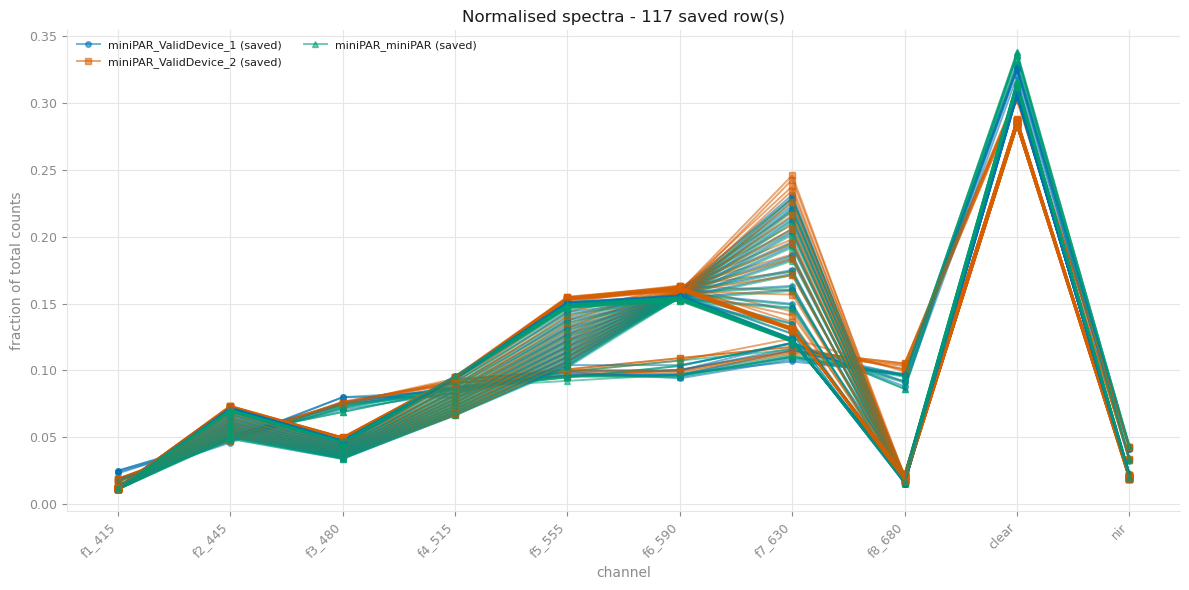

Left the capture loop. Serial ports are still open.


In [43]:
readings_df = load_readings()
print(f'{len(readings_df)} row(s) in {CSV_PATH}, next measurement id = {next_measurement_id()}')
print(f'{len(DEVICES)} device(s): ' + ', '.join(d.label for d in DEVICES))

while True:
    key = input('[Enter] capture   |   q + [Enter] quit : ').strip().lower()
    if key in {'q', 'quit', 'exit', 'esc'}:
        print('Left the capture loop. Serial ports are still open.')
        break

    try:
        reading = read_stable_multi(verbose=True)
    except Exception as exc:
        print(f'Read failed: {exc}')
        continue

    clear_output(wait=True)
    show_capture(reading)

    summary = pd.DataFrame([
        {'miniPAR': label, 'total': d['spec'].sum(), 'clear': d['spec'][SPECTRAL_CHANNELS.index('clear')],
         'spread_%': round(d['spread'] * 100, 2), 'gain': d['gain'], 'aint': d['aint'],
         'astep': d['astep'], 'saturated': ', '.join(d['saturated']) or '-'}
        for label, d in reading['devices'].items()])
    display(summary)

    print(f"TIA PAR   : {reading['tia_par']:.4f}  (spread {reading['tia_spread'] * 100:.2f} %)")
    print(f"stability : {'OK' if reading['stable'] else 'NOT REACHED'} - "
          f"{reading['n_samples']} samples in {reading['elapsed_s']:.1f} s")
    hot = [label for label, d in reading['devices'].items() if d['saturated']]
    if hot:
        print(f"SATURATED : {', '.join(hot)} - lower gain or aint before saving")
    if not reading['stable']:
        print('WARNING   : at least one signal was still drifting when this was taken.')

    metadata = input('metadata tag to save this capture (blank = discard): ').strip()
    if not metadata:
        print('Discarded.')
        continue

    measurement = next_measurement_id()          # re-read from the file, so it stays unique
    rows = reading_to_rows(reading, metadata, measurement)
    append_rows(rows)
    readings_df = pd.concat([readings_df, pd.DataFrame(rows, columns=CSV_COLUMNS)],
                            ignore_index=True)
    clear_output(wait=True)
    print(f'Saved measurement {measurement} ({len(rows)} rows) to {CSV_PATH}  '
          f'- {len(readings_df)} rows total')
    plot_spectra(readings_df)


## 9. Review what was collected


117 rows / 39 measurement(s) in c:\Users\LudovicoCaracciolo\Documents\Git-repo\miniPar\data\multi_par_spec.csv


,timestamp,measurement,tia_par,miniPAR,metadata,f1_415,f2_445,f3_480,f4_515,f5_555,f6_590,f7_630,f8_680,clear,nir,gain,aint,astep
107,2026-08-10T14:29:27,36,1116.63675,miniPAR_miniPAR,fluorcam act1 0 act2 100 fr 30,174.0,1009.0,670.0,1370.0,2138.0,2215.0,1764.0,255.0,4502.0,280.0,2,100,999
108,2026-08-10T14:29:42,37,1116.50140,miniPAR_ValidDevice_1,fluorcam act1 0 act2 100 fr 20,176.0,1045.0,686.0,1379.0,2182.0,2251.5,1786.0,243.0,4455.0,276.0,2,100,999
109,2026-08-10T14:29:42,37,1116.50140,miniPAR_ValidDevice_2,fluorcam act1 0 act2 100 fr 20,175.0,1045.0,710.0,1355.0,2203.0,2311.0,1875.0,260.0,4047.0,267.0,2,100,999
110,2026-08-10T14:29:42,37,1116.50140,miniPAR_miniPAR,fluorcam act1 0 act2 100 fr 20,173.0,1009.0,669.0,1369.0,2137.0,2214.0,1764.0,246.0,4484.0,278.0,2,100,999
111,2026-08-10T14:29:59,38,1116.54650,miniPAR_ValidDevice_1,fluorcam act1 0 act2 100 fr 10,176.0,1044.5,685.0,1379.0,2181.0,2251.0,1786.0,233.0,4438.5,274.0,2,100,999
112,2026-08-10T14:29:59,38,1116.54650,miniPAR_ValidDevice_2,fluorcam act1 0 act2 100 fr 10,175.0,1044.0,709.0,1354.0,2201.5,2310.0,1874.5,251.0,4029.5,265.0,2,100,999
113,2026-08-10T14:29:59,38,1116.54650,miniPAR_miniPAR,fluorcam act1 0 act2 100 fr 10,173.0,1008.0,668.0,1369.0,2136.0,2213.0,1762.0,236.0,4466.5,276.0,2,100,999
114,2026-08-10T14:30:16,39,1116.32070,miniPAR_ValidDevice_1,fluorcam act1 0 act2 100 fr 0,175.0,1044.0,684.0,1378.0,2180.0,2250.0,1784.5,226.0,4423.0,273.0,2,100,999
115,2026-08-10T14:30:16,39,1116.32070,miniPAR_ValidDevice_2,fluorcam act1 0 act2 100 fr 0,174.0,1043.0,709.0,1354.0,2201.0,2309.0,1874.0,244.0,4016.5,263.0,2,100,999
116,2026-08-10T14:30:16,39,1116.32070,miniPAR_miniPAR,fluorcam act1 0 act2 100 fr 0,172.0,1007.0,668.0,1368.0,2135.0,2212.0,1761.0,229.0,4451.5,274.0,2,100,999



Per device:


,rows,measurements,mean_total,std_total
miniPAR,,,,
miniPAR_ValidDevice_1,39,39,13992.333333,6941.795545
miniPAR_ValidDevice_2,39,39,13777.794872,6838.648345
miniPAR_miniPAR,39,39,13863.128205,6881.176809


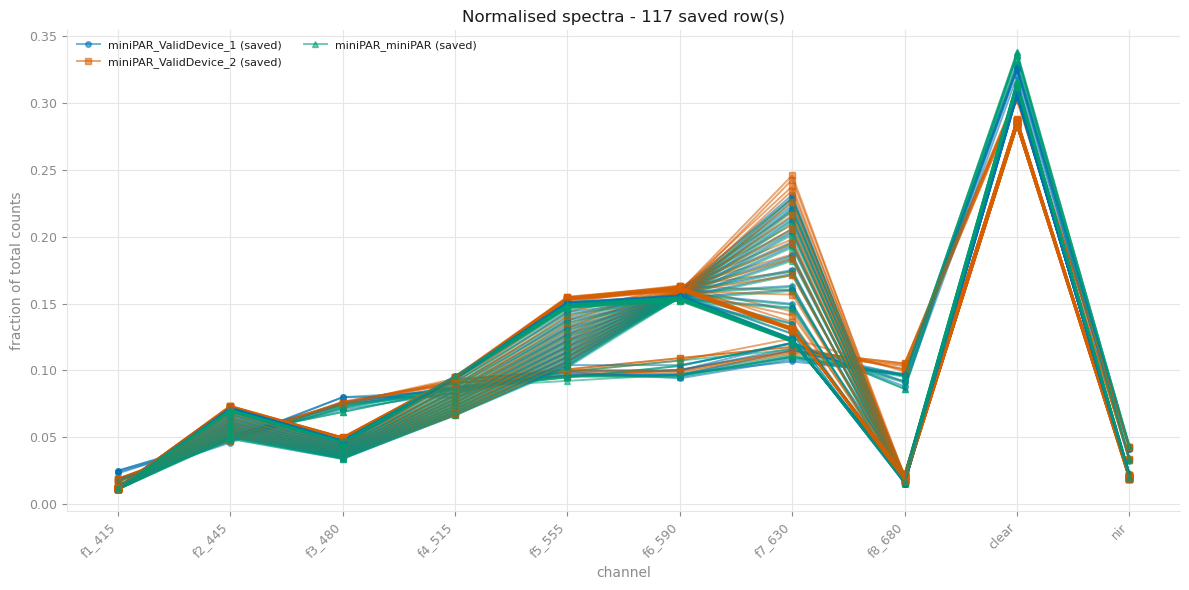

In [44]:
df = load_readings()
if df.empty:
    print(f'No readings yet in {CSV_PATH}')
else:
    print(f'{len(df)} rows / {df["measurement"].nunique()} measurement(s) in {CSV_PATH}')
    display(df.tail(10))

    print('\nPer device:')
    tagged = df.assign(spec_total=df[SPECTRAL_CHANNELS].sum(axis=1))
    display(tagged.groupby('miniPAR').agg(rows=('measurement', 'size'),
                                          measurements=('measurement', 'nunique'),
                                          mean_total=('spec_total', 'mean'),
                                          std_total=('spec_total', 'std')))

    incomplete = df.groupby('measurement')['miniPAR'].nunique()
    odd = incomplete[incomplete != incomplete.max()]
    if len(odd):
        print(f'\nMeasurements missing a device: {list(odd.index)}')

    saturated = (df[SPECTRAL_CHANNELS] >= SATURATION_COUNT).any(axis=1)
    if saturated.any():
        print(f'\n{int(saturated.sum())} row(s) contain a saturated channel:')
        display(df.loc[saturated, ['measurement', 'miniPAR', 'metadata', 'tia_par'] + SETTING_COLUMNS])

    plot_spectra(df)


## 10. Release the serial ports


In [45]:
close_links()
print('Serial ports closed. Re-run open_links() to reconnect.')


Serial ports closed. Re-run open_links() to reconnect.
